# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [4]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /home/parksad/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [5]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [6]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt")).astype(np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(np.int32) - 1
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt")).astype(np.float32)
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection

In [7]:
label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [8]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-07-16 15:47:05.340864: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:0a:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-16 15:47:05.341251: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Train the Baseline Model

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 1s 4ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0713 - accuracy: 0.9719 - val_loss: 0.2238 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0615 - accuracy: 0.9764 - val_loss: 0.1368 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves

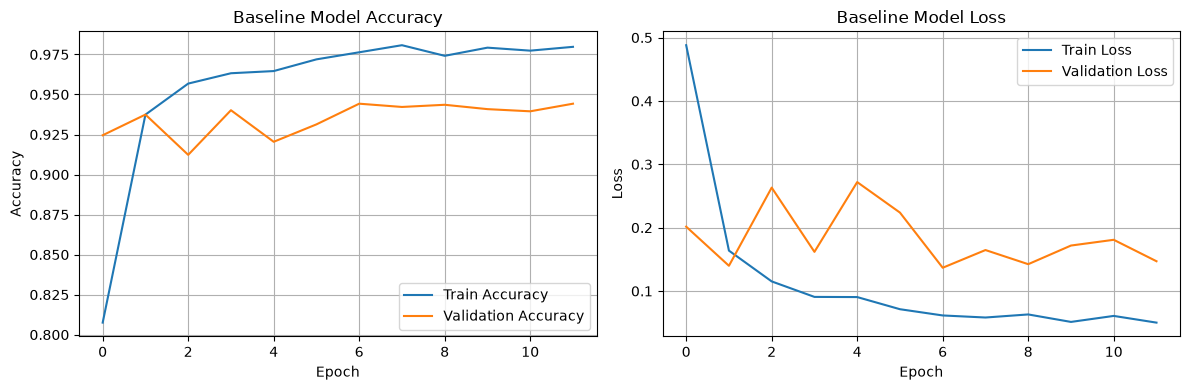

In [10]:
history_df = pd.DataFrame(baseline_history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["accuracy"], label="Train Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline Model Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_df["loss"], label="Train Loss")
axes[1].plot(history_df["val_loss"], label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Baseline Model Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 6. Evaluate the Baseline Keras Model

Baseline Keras Test Accuracy: 0.9243

                    precision    recall  f1-score   support

           WALKING     0.9042    0.9899    0.9451       496
  WALKING_UPSTAIRS     0.8835    0.9342    0.9082       471
WALKING_DOWNSTAIRS     0.9885    0.8190    0.8958       420
           SITTING     0.9315    0.8859    0.9081       491
          STANDING     0.8666    0.9398    0.9017       532
            LAYING     1.0000    0.9572    0.9781       537

          accuracy                         0.9243      2947
         macro avg     0.9291    0.9210    0.9228      2947
      weighted avg     0.9281    0.9243    0.9242      2947



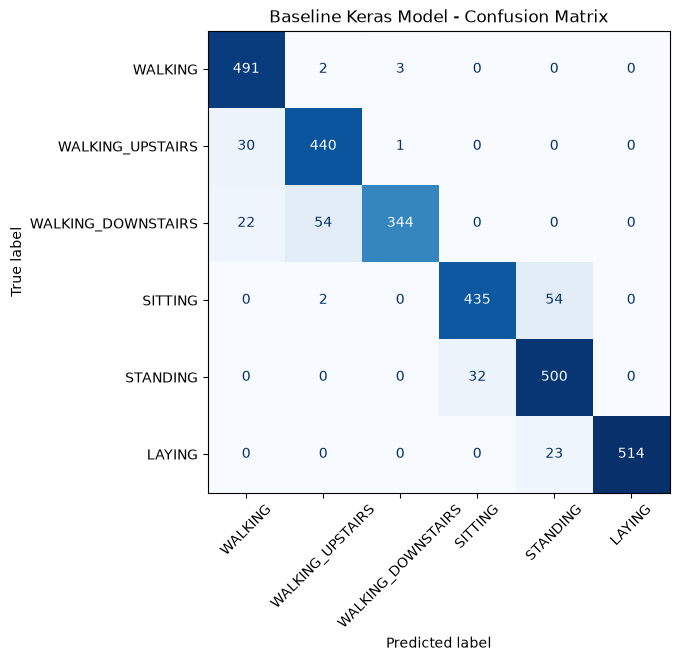

In [11]:
baseline_probs = baseline_model.predict(X_test, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc = accuracy_score(y_test, baseline_preds)

print(f"Baseline Keras Test Accuracy: {baseline_acc:.4f}\n")
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Keras Model - Confusion Matrix")
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [12]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [13]:
baseline_fp32_tflite = convert_to_tflite_fp32(baseline_model)
baseline_fp32_size_kb = save_binary_model(baseline_fp32_tflite, "baseline_fp32.tflite")
baseline_fp32_acc, baseline_fp32_preds = evaluate_tflite_model(baseline_fp32_tflite, X_test, y_test)

print(f"Baseline FP32 TFLite - Acc: {baseline_fp32_acc:.4f}, Size: {baseline_fp32_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmp6tnaw_yj/assets


INFO:tensorflow:Assets written to: /tmp/tmp6tnaw_yj/assets
2026-07-16 15:47:08.702817: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-16 15:47:08.702864: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Baseline FP32 TFLite - Acc: 0.9243, Size: 726.72 KB


2026-07-16 15:47:08.703071: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp6tnaw_yj
2026-07-16 15:47:08.703728: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-16 15:47:08.703739: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp6tnaw_yj
2026-07-16 15:47:08.706419: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-07-16 15:47:08.707055: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-16 15:47:08.737699: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp6tnaw_yj
2026-07-16 15:47:08.745023: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 41951 microseconds.
2026-07-16 15:47:08.754412: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR cr

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [14]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}

pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

pruning_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)


Epoch 1/12
92/92 [==============================] - 2s 4ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 0s 3ms/step - loss: 0.1662 - accuracy: 0.9373 - val_loss: 0.1596 - val_accuracy: 0.9286
Epoch 3/12
92/92 [==============================] - 0s 3ms/step - loss: 0.1310 - accuracy: 0.9493 - val_loss: 0.2198 - val_accuracy: 0.9279
Epoch 4/12
92/92 [==============================] - 0s 3ms/step - loss: 0.0920 - accuracy: 0.9691 - val_loss: 0.1562 - val_accuracy: 0.9354
Epoch 5/12
92/92 [==============================] - 0s 3ms/step - loss: 0.1559 - accuracy: 0.9429 - val_loss: 0.1403 - val_accuracy: 0.9395
Epoch 6/12
92/92 [==============================] - 0s 3ms/step - loss: 0.1319 - accuracy: 0.9565 - val_loss: 0.1508 - val_accuracy: 0.9334
Epoch 7/12
92/92 [==============================] - 0s 3ms/step - loss: 0.3422 - accuracy: 0.9221 - val_loss: 0.1753 - val_accuracy: 0.9313
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [15]:
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

stripped_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned (with mask) - Acc: {pruned_with_mask_acc:.4f}, Size: {pruned_with_mask_size_kb:.2f} KB")
print(f"Stripped Sparse     - Acc: {stripped_sparse_acc:.4f}, Size: {stripped_sparse_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmp10l5c_z8/assets


INFO:tensorflow:Assets written to: /tmp/tmp10l5c_z8/assets
2026-07-16 15:47:14.123743: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-16 15:47:14.123781: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-16 15:47:14.123907: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp10l5c_z8
2026-07-16 15:47:14.127169: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-16 15:47:14.127184: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp10l5c_z8
2026-07-16 15:47:14.136233: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-16 15:47:14.177323: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp10l5c_z8
2026-07-16 15:47:14.190078: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpdy3km3kp/assets


INFO:tensorflow:Assets written to: /tmp/tmpdy3km3kp/assets
2026-07-16 15:47:14.852348: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-16 15:47:14.852382: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-16 15:47:14.852499: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpdy3km3kp
2026-07-16 15:47:14.852901: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-16 15:47:14.852910: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpdy3km3kp
2026-07-16 15:47:14.853814: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-16 15:47:14.865211: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpdy3km3kp
2026-07-16 15:47:14.869492: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Pruned (with mask) - Acc: 0.9230, Size: 1454.18 KB
Stripped Sparse     - Acc: 0.9230, Size: 338.85 KB


## 11. Part I Comparison: Accuracy and Model Size

In [16]:
part1_results = pd.DataFrame([
    ["Baseline", "FP32", baseline_fp32_acc, baseline_fp32_size_kb],
    ["Pruned (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part1_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32,0.924330,726.718750
1,Pruned (with mask),FP32,0.922973,1454.175781
2,Stripped Sparse,FP32 + Sparse,0.922973,338.851562


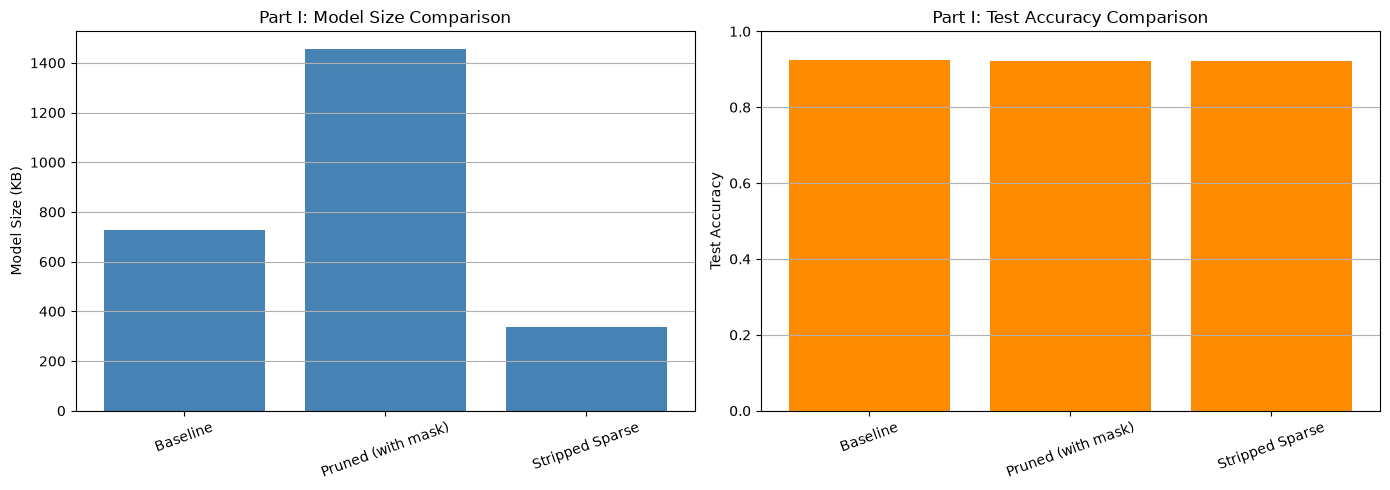

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(part1_results["Model"], part1_results["Model Size (KB)"], color="steelblue")
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part I: Model Size Comparison")
axes[0].grid(axis="y")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(part1_results["Model"], part1_results["Test Accuracy"], color="darkorange")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Part I: Test Accuracy Comparison")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse Model

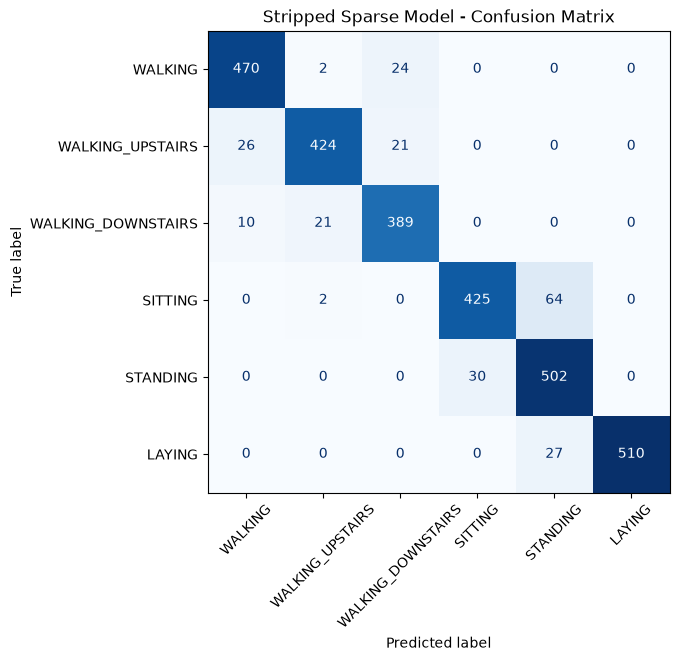

                    precision    recall  f1-score   support

           WALKING     0.9289    0.9476    0.9381       496
  WALKING_UPSTAIRS     0.9443    0.9002    0.9217       471
WALKING_DOWNSTAIRS     0.8963    0.9262    0.9110       420
           SITTING     0.9341    0.8656    0.8985       491
          STANDING     0.8465    0.9436    0.8924       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.9230      2947
         macro avg     0.9250    0.9221    0.9227      2947
      weighted avg     0.9257    0.9230    0.9234      2947



In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse Model - Confusion Matrix")
plt.show()

print(classification_report(y_test, stripped_sparse_preds, target_names=class_names, digits=4))


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [19]:
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_float16_with_mask_tflite = converter.convert()

pruned_float16_with_mask_size_kb = save_binary_model(
    pruned_float16_with_mask_tflite, "pruned_with_mask_float16.tflite"
)
pruned_float16_with_mask_acc, pruned_float16_with_mask_preds = evaluate_tflite_model(
    pruned_float16_with_mask_tflite, X_test, y_test
)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]
converter.target_spec.supported_types = [tf.float16]
stripped_sparse_float16_tflite = converter.convert()

stripped_sparse_float16_size_kb = save_binary_model(
    stripped_sparse_float16_tflite, "stripped_sparse_float16.tflite"
)
stripped_sparse_float16_acc, stripped_sparse_float16_preds = evaluate_tflite_model(
    stripped_sparse_float16_tflite, X_test, y_test
)

print(f"Pruned Float16 (with mask) - Acc: {pruned_float16_with_mask_acc:.4f}, Size: {pruned_float16_with_mask_size_kb:.2f} KB")
print(f"Stripped Sparse + Float16  - Acc: {stripped_sparse_float16_acc:.4f}, Size: {stripped_sparse_float16_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmpevu56ryg/assets


INFO:tensorflow:Assets written to: /tmp/tmpevu56ryg/assets
2026-07-16 15:47:17.041476: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-16 15:47:17.041519: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-16 15:47:17.041654: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpevu56ryg
2026-07-16 15:47:17.044783: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-16 15:47:17.044801: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpevu56ryg
2026-07-16 15:47:17.054525: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-16 15:47:17.102109: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpevu56ryg
2026-07-16 15:47:17.121219: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpd2l6jqai/assets


INFO:tensorflow:Assets written to: /tmp/tmpd2l6jqai/assets
2026-07-16 15:47:17.794645: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-16 15:47:17.794687: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-16 15:47:17.794806: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpd2l6jqai
2026-07-16 15:47:17.795264: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-16 15:47:17.795275: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpd2l6jqai
2026-07-16 15:47:17.796232: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-16 15:47:17.811021: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpd2l6jqai
2026-07-16 15:47:17.815446: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Pruned Float16 (with mask) - Acc: 0.9230, Size: 732.59 KB
Stripped Sparse + Float16  - Acc: 0.9230, Size: 223.71 KB


## 12. Part II Comparison: Accuracy and Model Size

In [20]:
part2_results = pd.DataFrame([
    ["Pruned (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Pruned (with mask)", "Float16", pruned_float16_with_mask_acc, pruned_float16_with_mask_size_kb],
    ["Stripped Sparse", "Float16 + Sparse", stripped_sparse_float16_acc, stripped_sparse_float16_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Pruned (with mask),FP32,0.922973,1454.175781
1,Stripped Sparse,FP32 + Sparse,0.922973,338.851562
2,Pruned (with mask),Float16,0.922973,732.585938
3,Stripped Sparse,Float16 + Sparse,0.922973,223.710938


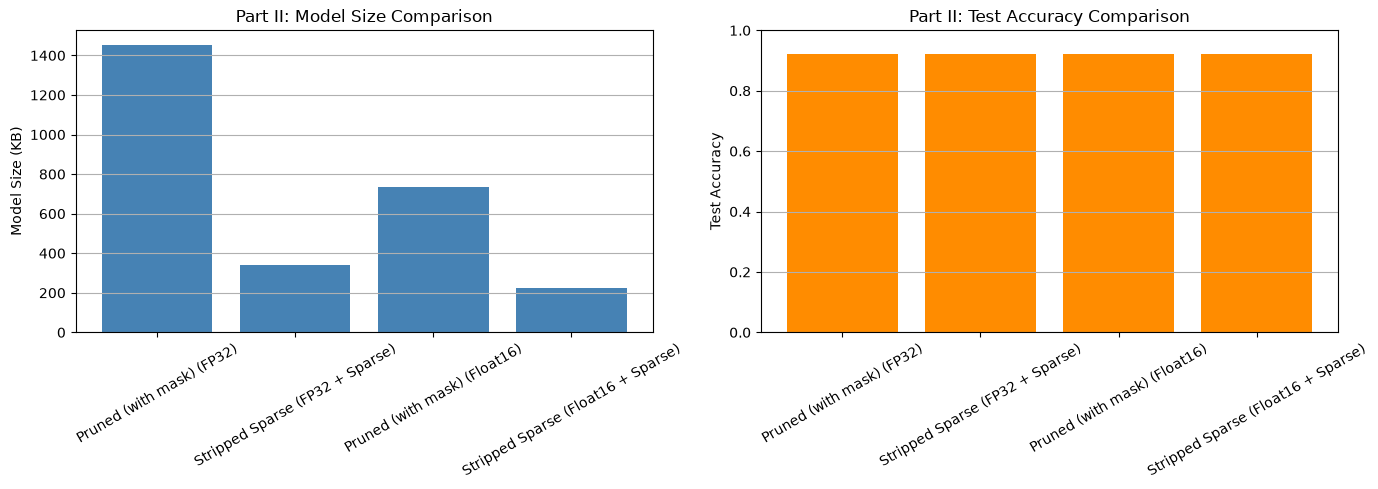

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = part2_results["Model"] + " (" + part2_results["Format"] + ")"

axes[0].bar(labels, part2_results["Model Size (KB)"], color="steelblue")
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part II: Model Size Comparison")
axes[0].grid(axis="y")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(labels, part2_results["Test Accuracy"], color="darkorange")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Part II: Test Accuracy Comparison")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

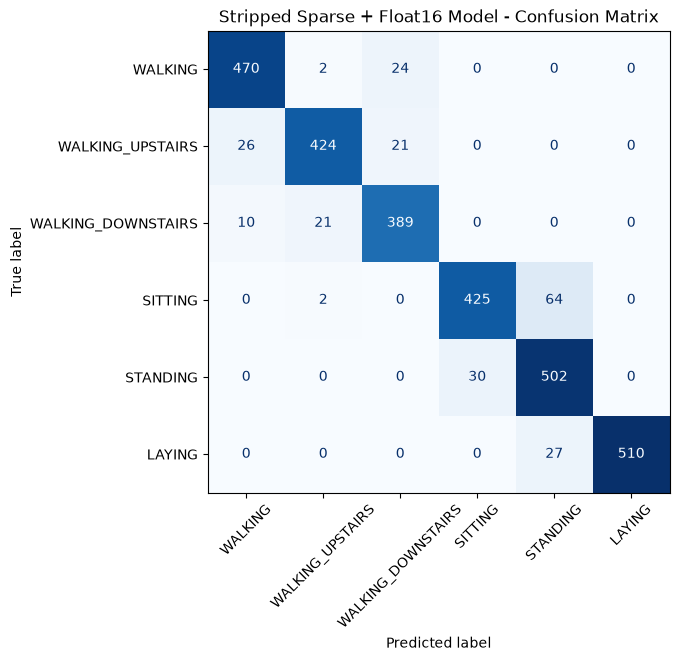

                    precision    recall  f1-score   support

           WALKING     0.9289    0.9476    0.9381       496
  WALKING_UPSTAIRS     0.9443    0.9002    0.9217       471
WALKING_DOWNSTAIRS     0.8963    0.9262    0.9110       420
           SITTING     0.9341    0.8656    0.8985       491
          STANDING     0.8465    0.9436    0.8924       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.9230      2947
         macro avg     0.9250    0.9221    0.9227      2947
      weighted avg     0.9257    0.9230    0.9234      2947



In [22]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_float16_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse + Float16 Model - Confusion Matrix")
plt.show()

print(classification_report(y_test, stripped_sparse_float16_preds, target_names=class_names, digits=4))


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
No, it got bigger as the mask adds overhead (1454KB from 726KB).
2. Why does `strip_pruning(...)` matter before export?
Because without it you're still storing the mask and dense weights together. With it will remove the dead weight so it can actually make a smaller file.
3. Which model had the smallest file size in this notebook?
Stripped sparse + float16 at 223.71KB.
4. Did float16 quantization noticeably change the test accuracy?
Not really, it stayed around 92.3% the whole time.
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
Stripped sparse + float16 because it is the smallest size with basically no damage to the accuracy.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
